### 2.1 Implicit Feedback Models

Collaborative filtering algorithms can be divided into two major categories:

- **Explicit feedback**, where users directly express preferences through ratings (e.g., 1–5 stars).
- **Implicit feedback**, where preferences are inferred from user behavior such as page views, clicks, purchases, or watch history.

The RetailRocket dataset contains only implicit feedback. Therefore, recommendation models must learn from observed user interactions rather than explicit ratings.

One of the most widely used approaches for this scenario is **Alternating Least Squares (ALS)** for implicit feedback, proposed by Hu, Koren, and Volinsky (2008).

In this notebook we will:

- prepare implicit interaction data;
- build a sparse user-item interaction matrix;
- train an Implicit ALS model;
- generate recommendations;
- evaluate recommendation quality.

### 2.2 Preparing Interaction Data

In [1]:
import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix

import matplotlib.pyplot as plt
import plotly.express as px

from pathlib import Path

import implicit
import lightfm
import faiss
import hnswlib
import torch

print("Everything works!")

/Users/aleksandrzelenskij/Desktop/github/advanced-recommender-systems/.venv/lib/python3.9/site-packages/lightfm/_lightfm_fast.py:9: UserWarning: LightFM was compiled without OpenMP support. Only a single thread will be used.
  warnings.warn(


Everything works!


In [2]:
DATA_DIR = Path("../data/raw")

category_tree_path = DATA_DIR / "category_tree.csv"
events_path = DATA_DIR / "events.csv"
item_properties_p1_path = DATA_DIR / "item_properties_part1.csv"
item_properties_p2_path = DATA_DIR / "item_properties_part2.csv"

In [3]:
category_tree = pd.read_csv(category_tree_path)
events = pd.read_csv(events_path)
item_properties_p1 = pd.read_csv(item_properties_p1_path)
item_properties_p2 = pd.read_csv(item_properties_p2_path)

In [4]:
events["event"].value_counts()

event
view           2664312
addtocart        69332
transaction      22457
Name: count, dtype: int64

In [5]:
EVENT_WEIGHTS = {
    "view": 1,
    "addtocart": 3,
    "transaction": 5,
}

In [6]:
events["weight"] = events["event"].map(EVENT_WEIGHTS)

In [7]:
interactions = (
    events
    .groupby(["visitorid", "itemid"])["weight"]
    .sum()
    .reset_index()
)

In [8]:
interactions.head()

,visitorid,itemid,weight
0,0,67045,1
1,0,285930,1
2,0,357564,1
3,1,72028,1
4,2,216305,2


### 2.3 Building User-Item Matrix

In [9]:
interactions["user_id"] = interactions["visitorid"].astype("category").cat.codes
interactions["item_id"] = interactions["itemid"].astype("category").cat.codes

In [10]:
interaction_matrix = csr_matrix(
    (
        interactions["weight"],
        (
            interactions["user_id"],
            interactions["item_id"],
        )
    )
)

In [11]:
print(interaction_matrix.shape)
print(interaction_matrix.nnz)

(1407580, 235061)
2145179


In [12]:
interaction_matrix

<1407580x235061 sparse matrix of type '<class 'numpy.int64'>'
	with 2145179 stored elements in Compressed Sparse Row format>

### 2.4 Implicit ALS

### 2.4.1 From Explicit ALS to Implicit ALS

Alternating Least Squares (ALS) is a latent-factor model that can be used for recommendation systems based on implicit user feedback.

Unlike explicit-feedback recommendation, users do not provide direct ratings such as 1–5 stars. Instead, the model learns from observed user behavior, such as product views, add-to-cart actions, and transactions.

In this project, different interaction types are converted into interaction weights:

- `view` → 1
- `addtocart` → 3
- `transaction` → 5

These weights represent the strength of the observed interaction.

The user-item interaction matrix is defined as

$$
R \in \mathbb{R}^{m \times n},
$$

where:

- $m$ is the number of users;
- $n$ is the number of items;
- $r_{ui}$ represents the aggregated strength of interaction between user $u$ and item $i$.

The matrix is extremely sparse because each user interacts with only a small fraction of all available items.

### Latent Factorization

Similarly to explicit-feedback ALS, we approximate the interaction matrix using two low-dimensional latent-factor matrices:

$$
R \approx P Q^T,
$$

where:

- $P \in \mathbb{R}^{m \times k}$ contains latent representations of users;
- $Q \in \mathbb{R}^{n \times k}$ contains latent representations of items;
- $k$ is the number of latent factors.

A user's latent vector is

$$
p_u \in \mathbb{R}^k,
$$

while an item's latent representation is

$$
q_i \in \mathbb{R}^k.
$$

The predicted preference between user $u$ and item $i$ is obtained from their dot product:

$$
\hat{r}_{ui} = p_u^T q_i.
$$

However, implicit feedback requires a different interpretation of the observed values.

The absence of an interaction does not necessarily mean that the user dislikes the item. It usually means that we simply do not have evidence about the user's preference.

Therefore, instead of treating zero values as explicit negative ratings, we distinguish between:

- **preference** — whether an interaction was observed;
- **confidence** — how strongly we trust the observed interaction.

For an observed interaction, we define the preference as

$$
p_{ui} =
\begin{cases}
1, & r_{ui} > 0, \\
0, & r_{ui} = 0.
\end{cases}
$$

The confidence is defined as

$$
c_{ui} = 1 + \alpha r_{ui},
$$

where $\alpha$ controls how strongly the interaction strength affects the model.

Thus, a transaction receives higher confidence than a simple product view.

### Objective Function

The model minimizes the confidence-weighted reconstruction error:

$$
\min_{P,Q}
\sum_{u,i}
c_{ui}
\left(
p_{ui} - p_u^T q_i
\right)^2
+
\lambda
\left(
\|P\|_F^2 + \|Q\|_F^2
\right).
$$

Here:

- $p_{ui}$ is the binary preference;
- $c_{ui}$ is the confidence of the observation;
- $p_u^T q_i$ is the predicted preference;
- $\lambda$ is the L2 regularization parameter.

The confidence term determines how strongly each observation contributes to the loss.

For example, if a user only viewed an item, the model receives a relatively weak signal. If the user added the item to the cart or purchased it, the corresponding error receives a larger weight.

### Alternating Optimization

As in explicit-feedback ALS, the optimization alternates between user and item latent factors.

First, the item matrix $Q$ is fixed and all user vectors are optimized.

Then, the user matrix $P$ is fixed and all item vectors are optimized.

For a particular user $u$, the optimal latent vector is obtained by solving:

$$
p_u =
\left(
Q^T C_u Q + \lambda I
\right)^{-1}
Q^T C_u p(u),
$$

where:

- $C_u$ is a diagonal matrix containing confidence values for user $u$;
- $p(u)$ contains the user's binary preferences;
- $I$ is the identity matrix.

The same procedure is then applied to update each item vector.

This alternating procedure is repeated for a predefined number of iterations until the latent factors converge.

The main difference from explicit-feedback ALS is therefore the use of confidence-weighted implicit feedback rather than direct numerical ratings.

#### 2.4.2 Preference and Confidence

In [22]:
interaction_matrix

<1407580x235061 sparse matrix of type '<class 'numpy.int64'>'
	with 2145179 stored elements in Compressed Sparse Row format>

In [19]:
interactions

,visitorid,itemid,weight,user_id,item_id
0,0,67045,1,0,33901
1,0,285930,1,0,144072
2,0,357564,1,0,180182
3,1,72028,1,1,36440
4,2,216305,2,2,108948
...,...,...,...,...,...
2145174,1407575,121220,1,1407575,61283
2145175,1407576,356208,1,1407576,179485
2145176,1407577,427784,1,1407577,215448
2145177,1407578,188736,1,1407578,95116


In [20]:
alpha = 1

preference = (interactions["weight"] > 0).astype(float)

confidence = 1 + alpha * interactions["weight"]

#### 2.4.3 One ALS Iteratio#### 2.4.3 One ALS Iteration

To understand how Implicit ALS works in practice, we first use a small synthetic user-item matrix.

The matrix contains 3 users and 4 items. The values represent the aggregated interaction strength between users and items.

We then derive:

- **Preference** — whether an interaction was observed;
- **Confidence** — how strongly we trust each observation.

Both user and item latent-factor matrices are initialized randomly.

During one ALS iteration:

1. The item matrix $Q$ is fixed and the user matrix $P$ is updated analytically.
2. The updated user matrix $P$ is fixed and the item matrix $Q$ is updated analytically.
3. The confidence-weighted objective function is evaluated before and after the iteration.

The goal is to verify that one ALS iteration reduces the optimization objective.n

In [37]:
# Small example
alpha = 1
R_demo = np.array([
    [2, 0, 0, 5],
    [0, 3, 0, 0],
    [1, 0, 4, 0]
])

preference_demo = (R_demo > 0).astype(float)
confidence_demo = 1 + alpha * R_demo

print("R:")
print(R_demo)

print("\nPreference:")
print(preference_demo)

print("\nConfidence:")
print(confidence_demo)

R:
[[2 0 0 5]
 [0 3 0 0]
 [1 0 4 0]]

Preference:
[[1. 0. 0. 1.]
 [0. 1. 0. 0.]
 [1. 0. 1. 0.]]

Confidence:
[[3 1 1 6]
 [1 4 1 1]
 [2 1 5 1]]


In [38]:
# Initialization of the user (P) and item (Q) matrices

np.random.seed(42)

n_users, n_items = R_demo.shape
n_factors = 2

P = np.random.normal(
    scale=0.1,
    size=(n_users, n_factors)
)

Q = np.random.normal(
    scale=0.1,
    size=(n_items, n_factors)
)

# Save initial factors for comparison
P_initial = P.copy()
Q_initial = Q.copy()

print("Initial P:")
print(P)

print("\nInitial Q:")
print(Q)

Initial P:
[[ 0.04967142 -0.01382643]
 [ 0.06476885  0.15230299]
 [-0.02341534 -0.0234137 ]]

Initial Q:
[[ 0.15792128  0.07674347]
 [-0.04694744  0.054256  ]
 [-0.04634177 -0.04657298]
 [ 0.02419623 -0.19132802]]


In [39]:
def calculate_loss(P, Q, preference, confidence, lambda_reg):
    
    predictions = P @ Q.T
    
    reconstruction_loss = np.sum(
        confidence * (preference - predictions) ** 2
    )
    
    regularization_loss = lambda_reg * (
        np.sum(P ** 2) +
        np.sum(Q ** 2)
    )
    
    return reconstruction_loss + regularization_loss

In [40]:
lambda_reg = 0.1

loss_before = calculate_loss(
    P,
    Q,
    preference_demo,
    confidence_demo,
    lambda_reg
)

print(f"Loss before ALS iteration: {loss_before:.4f}")

Loss before ALS iteration: 19.8842


In [41]:
# Analytical update of P

for u in range(R_demo.shape[0]):
    
    y_u = preference_demo[u]
    c_u = confidence_demo[u]
    
    C_u = np.diag(c_u)
    
    A = (
        Q.T @ C_u @ Q
        + lambda_reg * np.eye(n_factors)
    )
    
    b = Q.T @ C_u @ y_u
    
    P[u] = np.linalg.solve(A, b)

print("Updated P:")
print(P)

Updated P:
[[ 3.51205194 -2.76418368]
 [-1.37039183  1.38253378]
 [ 0.61635302 -0.59531939]]


In [42]:
# Analytical update of Q

for i in range(R_demo.shape[1]):
    
    y_i = preference_demo[:, i]
    c_i = confidence_demo[:, i]
    
    C_i = np.diag(c_i)
    
    A = (
        P.T @ C_i @ P
        + lambda_reg * np.eye(n_factors)
    )
    
    b = P.T @ C_i @ y_i
    
    Q[i] = np.linalg.solve(A, b)

print("Updated Q:")
print(Q)

Updated Q:
[[ 0.06155275 -0.293606  ]
 [ 1.36477943  1.88193763]
 [-1.03047841 -1.47261415]
 [ 0.61158774  0.42359678]]


In [43]:
loss_after = calculate_loss(
    P,
    Q,
    preference_demo,
    confidence_demo,
    lambda_reg
)

print(f"Loss before ALS iteration: {loss_before:.4f}")
print(f"Loss after ALS iteration:  {loss_after:.4f}")

Loss before ALS iteration: 19.8842
Loss after ALS iteration:  8.9451


In [44]:
loss_reduction = (
    1 - loss_after / loss_before
) * 100

print(f"Loss reduction: {loss_reduction:.2f}%")

Loss reduction: 55.01%


In [45]:
predictions_before = P_initial @ Q_initial.T
predictions_after = P @ Q.T

print("Preference:")
print(preference_demo)

print("\nPredictions before ALS:")
print(predictions_before)

print("\nPredictions after ALS:")
print(predictions_after)

Preference:
[[1. 0. 0. 1.]
 [0. 1. 0. 0.]
 [1. 0. 1. 0.]]

Predictions before ALS:
[[ 0.00678309 -0.00308211 -0.00165792  0.00384724]
 [ 0.02191664  0.00522262 -0.01009471 -0.02757267]
 [-0.00549463 -0.00017104  0.00217555  0.00391313]]

Predictions after ALS:
[[ 1.02775737 -0.40884504  0.4514823   0.97702861]
 [-0.4902716   0.73155978 -0.62377962 -0.25247799]
 [ 0.21272757 -0.27916804  0.24153728  0.12477858]]


The dot product $p_u^T q_i$ is an unconstrained preference score rather than a probability.

Therefore, predictions are not required to lie in the $[0,1]$ interval. The absolute value of the score is less important than the relative ranking of items for a given user.

For recommendation generation, items can be ranked by their predicted preference scores and the top-$N$ items can be selected.

#### 2.4.4 Implementing `ImplicitALSModel`

In [49]:
class ImplicitALSModel:

    def __init__(
        self,
        factors=64,
        regularization=0.01,
        iterations=20,
        alpha=1.0,
        random_state=42,
        verbose=True
    ):
        self.factors = factors
        self.regularization = regularization
        self.iterations = iterations
        self.alpha = alpha
        self.random_state = random_state
        self.verbose = verbose

        self.P = None
        self.Q = None

        self.preference = None
        self.confidence = None

        self.loss_history = []

        self.n_users = None
        self.n_items = None

    def fit(self, R):

        # Make sure we work with CSR sparse matrix
        R = R.tocsr().astype(np.float64)

        self.n_users, self.n_items = R.shape

        # Preference matrix:
        # 1 if interaction was observed, 0 otherwise
        self.preference = R.copy()
        self.preference.data = np.ones_like(
            self.preference.data
        )

        # Confidence matrix:
        # c_ui = 1 + alpha * r_ui
        self.confidence = R.copy()
        self.confidence.data = (
            1 + self.alpha * self.confidence.data
        )

        # Random initialization
        rng = np.random.default_rng(
            self.random_state
        )

        self.P = rng.normal(
            scale=0.1,
            size=(self.n_users, self.factors)
        )

        self.Q = rng.normal(
            scale=0.1,
            size=(self.n_items, self.factors)
        )

        self.loss_history = []

        for epoch in range(self.iterations):

            # Update user factors
            self._update_users(R)

            # Update item factors
            self._update_items(R)

            # Calculate objective function
            loss = self.calculate_loss(R)

            self.loss_history.append(loss)

            if self.verbose:
                print(
                    f"Iteration {epoch + 1:2d} | "
                    f"Loss = {loss:.4f}"
                )

        return self

    def _update_users(self, R):

        I = np.eye(self.factors)

        # Q^T Q is shared by all users
        QtQ = self.Q.T @ self.Q

        for u in range(self.n_users):

            start = R.indptr[u]
            end = R.indptr[u + 1]

            item_indices = R.indices[start:end]
            weights = R.data[start:end]

            Q_u = self.Q[item_indices]

            # c_ui - 1 = alpha * r_ui
            confidence_minus_one = (
                self.alpha * weights
            )

            # A =
            # Q^T Q
            # + Q_u^T (C_u - I) Q_u
            # + lambda I
            A = QtQ.copy()

            A += (
                Q_u.T
                @ (
                    confidence_minus_one[:, None]
                    * Q_u
                )
            )

            A += (
                self.regularization * I
            )

            # b = Q_u^T C_u y_u
            #
            # y_u = 1 for observed interactions
            b = Q_u.T @ (
                1 + confidence_minus_one
            )

            self.P[u] = np.linalg.solve(A, b)

    def _update_items(self, R):

        I = np.eye(self.factors)

        # P^T P is shared by all items
        PtP = self.P.T @ self.P

        # CSC provides efficient column access
        R_csc = R.tocsc()

        for i in range(self.n_items):

            start = R_csc.indptr[i]
            end = R_csc.indptr[i + 1]

            user_indices = R_csc.indices[start:end]
            weights = R_csc.data[start:end]

            P_i = self.P[user_indices]

            # c_ui - 1 = alpha * r_ui
            confidence_minus_one = (
                self.alpha * weights
            )

            # A =
            # P^T P
            # + P_i^T (C_i - I) P_i
            # + lambda I
            A = PtP.copy()

            A += (
                P_i.T
                @ (
                    confidence_minus_one[:, None]
                    * P_i
                )
            )

            A += (
                self.regularization * I
            )

            # b = P_i^T C_i y_i
            b = P_i.T @ (
                1 + confidence_minus_one
            )

            self.Q[i] = np.linalg.solve(A, b)

    def predict(self, user_id, item_id):

        return (
            self.P[user_id]
            @ self.Q[item_id]
        )

    def calculate_loss(self, R):

        # ||P Q^T||_F^2
        #
        # = trace(P^T P Q^T Q)

        PtP = self.P.T @ self.P
        QtQ = self.Q.T @ self.Q

        reconstruction_loss = np.trace(
            PtP @ QtQ
        )

        # Correct the contribution of observed
        # interactions.
        for u in range(self.n_users):

            start = R.indptr[u]
            end = R.indptr[u + 1]

            item_indices = R.indices[start:end]
            weights = R.data[start:end]

            if len(item_indices) == 0:
                continue

            predictions = (
                self.P[u]
                @ self.Q[item_indices].T
            )

            confidence = (
                1 + self.alpha * weights
            )

            reconstruction_loss += np.sum(
                confidence * (1 - predictions) ** 2
                - predictions ** 2
            )

        regularization_loss = (
            self.regularization
            * (
                np.sum(self.P ** 2)
                + np.sum(self.Q ** 2)
            )
        )

        return (
            reconstruction_loss
            + regularization_loss
        )

#### 2.4.5 Training

We now train the implemented `ImplicitALSModel` on the RetailRocket interaction matrix.

The interaction matrix is stored as a sparse CSR matrix, allowing us to work with the extremely sparse user-item data without converting the full matrix to a dense representation.

During training, the model alternates between:

1. Updating user latent factors $P$ while keeping item factors $Q$ fixed.
2. Updating item latent factors $Q$ while keeping user factors $P$ fixed.
3. Calculating the confidence-weighted objective function.

The process is repeated for a predefined number of iterations.

We first train the model on the full interaction matrix and track the training loss to analyze convergence.

In [58]:
model = ImplicitALSModel(
    factors=64,
    regularization=0.01,
    iterations=5,
    alpha=1.0,
    random_state=42,
    verbose=True
)

In [67]:
import time

start_time = time.time()

model.fit(interaction_matrix)

training_time = time.time() - start_time

print(f"\nTraining time: {training_time:.2f} seconds")
print(f"Training time: {training_time / 60:.2f} minutes")

Iteration  1 | Loss = 5021211.7310
Iteration  2 | Loss = 4857846.9639
Iteration  3 | Loss = 4830448.7675
Iteration  4 | Loss = 4820301.2941
Iteration  5 | Loss = 4814793.7119

Training time: 372.82 seconds
Training time: 6.21 minutes


In [68]:
print("P shape:", model.P.shape)
print("Q shape:", model.Q.shape)

P shape: (1407580, 64)
Q shape: (235061, 64)


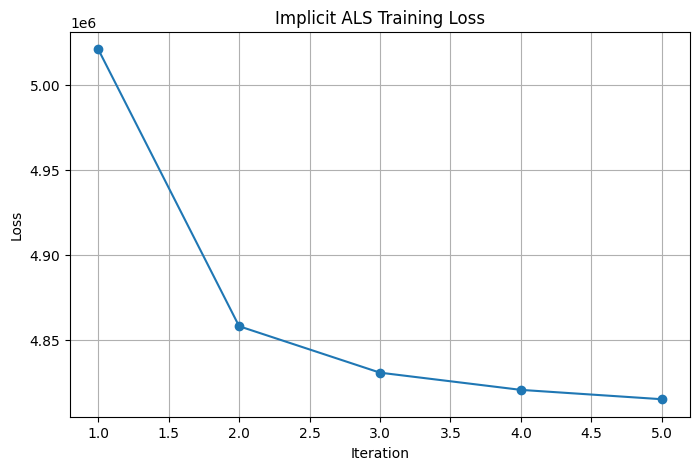

In [69]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(model.loss_history) + 1),
    model.loss_history,
    marker="o"
)

plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Implicit ALS Training Loss")
plt.grid(True)

plt.show()

In [70]:
print(f"Final loss: {model.loss_history[-1]:.4f}")
print(f"Loss reduction: "
      f"{(1 - model.loss_history[-1] / model.loss_history[0]) * 100:.2f}%")

Final loss: 4814793.7119
Loss reduction: 4.11%


#### Training Results

The implicit ALS model was trained using:

- 64 latent factors;
- L2 regularization coefficient of 0.01;
- confidence scaling parameter $\alpha = 1$;
- 5 ALS iterations.

The model converged quickly during the first iterations. The training loss decreased from approximately $5.02 \times 10^6$ after the first iteration to $4.81 \times 10^6$ after the fifth iteration.

Overall, the training loss decreased by approximately **4.11%**.

This confirms that the alternating optimization procedure successfully reduces the confidence-weighted reconstruction objective.

However, the training loss alone does not tell us how well the model generates recommendations for unseen items. Therefore, in the next section we evaluate the model using an offline recommendation setup.

#### 2.4.6 Evaluation

The quality of an implicit-feedback recommender system cannot be evaluated using the training loss alone.

The model is trained to reconstruct observed user preferences, but our actual goal is different: **to recommend relevant items that the user has not interacted with yet**.

Therefore, we evaluate the model using an offline recommendation setup.

The evaluation process consists of the following steps:

1. Split historical interactions into training and test sets using a temporal holdout strategy.
2. Train the Implicit ALS model using only the training interactions.
3. Generate Top-K recommendations for each user.
4. Compare the recommended items with the user's held-out test interaction.
5. Calculate ranking metrics such as Recall@K and Precision@K.

This allows us to evaluate the model from the perspective of its actual recommendation performance rather than its ability to minimize the training objective.

#### 2.4.6.1 Train/Test Split

Since recommender systems are used to predict future user behavior, a random train/test split is not appropriate for this task. Random splitting could allow the model to learn from interactions that happened after the interaction we are trying to predict.

Instead, we use a time-based rolling evaluation strategy.

The dataset contains approximately 137 days of interactions. We use the last 10 days as validation windows, with each test window containing exactly one day.

For each window:

- the training set contains all interactions before the test period;
- the test set contains interactions from the following day;
- the training period expands as we move forward in time;
- only users and items already observed in the training data are evaluated.

This setup represents a warm-start recommendation scenario, where the system has previously observed the user and the item and must predict the user's future interactions.

The resulting evaluation scheme is:

```text
Window 1
TRAIN: ────────────────────────────────
TEST:                                  DAY 1

Window 2
TRAIN: ───────────────────────────────────
TEST:                                      DAY 2

Window 3
TRAIN: ───────────────────────────────────────
TEST:                                            DAY 3

...

Window 10
TRAIN: ───────────────────────────────────────────────────────
TEST:                                                           DAY 10

In [129]:
# Aggregate interactions
interactions = (
    events
    .groupby(["visitorid", "itemid"])
    .agg(
        weight=("weight", "sum"),
        timestamp=("timestamp", "max")
    )
    .reset_index()
)

# Convert timestamp to datetime
interactions["datetime"] = pd.to_datetime(
    interactions["timestamp"],
    unit="ms"
)

# Create global user and item indices
interactions["user_idx"], user_mapping = pd.factorize(
    interactions["visitorid"]
)

interactions["item_idx"], item_mapping = pd.factorize(
    interactions["itemid"]
)

In [130]:
max_date

Timestamp('2015-09-18 02:59:47.788000')

In [133]:
n_windows = 10
test_days = 1

max_date = interactions["datetime"].max()

windows = []

for i in range(n_windows, 0, -1):

    test_start = (
        max_date
        - pd.DateOffset(days=i)
    )

    test_end = (
        test_start
        + pd.DateOffset(days=test_days)
    )

    train = interactions[
        interactions["datetime"] < test_start
    ].copy()

    test = interactions[
        (interactions["datetime"] >= test_start)
        & (interactions["datetime"] < test_end)
    ].copy()

    # Keep only users known during training
    known_users = train["user_idx"].unique()

    # Keep only items known during training
    known_items = train["item_idx"].unique()

    test = test[
        test["user_idx"].isin(known_users)
        & test["item_idx"].isin(known_items)
    ].copy()

    windows.append({
        "iteration": n_windows - i + 1,
        "train": train,
        "test": test,
        "train_end": test_start,
        "test_start": test_start,
        "test_end": test_end,
    })

In [135]:
for window in windows:

    train = window["train"]
    test = window["test"]

    print(
        f"Window {window['iteration']:2d} | "
        f"Train: {window['train_end'].date()} | "
        f"Test: {window['test_start'].date()} → "
        f"{window['test_end'].date()} | "
        f"Train interactions: {len(train):,} | "
        f"Test interactions: {len(test):,}"
    )

Window  1 | Train: 2015-09-08 | Test: 2015-09-08 → 2015-09-09 | Train interactions: 1,999,142 | Test interactions: 2,880
Window  2 | Train: 2015-09-09 | Test: 2015-09-09 → 2015-09-10 | Train interactions: 2,015,790 | Test interactions: 3,319
Window  3 | Train: 2015-09-10 | Test: 2015-09-10 → 2015-09-11 | Train interactions: 2,033,186 | Test interactions: 3,433
Window  4 | Train: 2015-09-11 | Test: 2015-09-11 → 2015-09-12 | Train interactions: 2,051,702 | Test interactions: 2,959
Window  5 | Train: 2015-09-12 | Test: 2015-09-12 → 2015-09-13 | Train interactions: 2,067,832 | Test interactions: 2,041
Window  6 | Train: 2015-09-13 | Test: 2015-09-13 → 2015-09-14 | Train interactions: 2,080,882 | Test interactions: 1,965
Window  7 | Train: 2015-09-14 | Test: 2015-09-14 → 2015-09-15 | Train interactions: 2,094,902 | Test interactions: 2,889
Window  8 | Train: 2015-09-15 | Test: 2015-09-15 → 2015-09-16 | Train interactions: 2,112,076 | Test interactions: 2,988
Window  9 | Train: 2015-09-16 | 

#### 2.4.6.2 Evaluation Metrics

For implicit-feedback recommendation, the main objective is not to predict an exact numerical rating. Instead, the model should rank items that the user is likely to interact with higher than other items.

Therefore, we evaluate the quality of the Top-K recommendation list rather than the reconstruction loss used during ALS training.

For each user:

1. The model computes a relevance score for candidate items.
2. Items are sorted by their predicted score.
3. The top K items are selected as recommendations.
4. The recommendations are compared with the items the user actually interacted with during the test period.

Only interactions observed in the test period are considered relevant.

A particularly important aspect of our evaluation is how much of the user's future behavior we are able to cover. If a user interacts with three items during the test period and two of them appear in the Top-K recommendations, the model covers 2 out of 3 relevant items, achieving a Recall@K of 66.7%.

This makes Recall@K especially useful for our dataset, where many users have only a small number of interactions.

We use three ranking metrics:

- Precision@K measures the proportion of recommended items that were relevant.
- Recall@K measures the proportion of relevant test items covered by the recommendations.
- NDCG@K measures how well relevant items are ranked, giving higher importance to relevant items appearing near the top of the recommendation list.

Items already observed by the user during training are excluded from the recommendation candidates. This ensures that the evaluation measures the ability of the model to recommend new items that the user interacts with in the future.

We evaluate the metrics for multiple values of K, such as K = 5, 10, and 20.

### Precision@K

Precision@K measures how many of the recommended items are actually relevant.

In our setting, an item is considered relevant if the user interacted with it during the test period.

For a user with $K$ recommendations:

$$
Precision@K =
\frac{|Recommendations_K \cap Relevant|}
{K}
$$

For example, suppose the model recommends 10 items and the user interacted with 2 of these items during the test period:

$$
Precision@10 = \frac{2}{10} = 0.20
$$

Thus, Precision@10 answers the question:

> **"What proportion of our recommendations turned out to be relevant?"**

Because many users in the RetailRocket dataset have only a small number of interactions, Precision@K can be relatively low even when the model successfully retrieves the user's relevant items.

In [110]:
def precision_at_k(recommended_items, relevant_items, k):
    
    recommended_items = recommended_items[:k]
    
    if len(recommended_items) == 0:
        return 0.0
    
    hits = len(
        set(recommended_items) & set(relevant_items)
    )
    
    return hits / k

### Recall@K

Recall@K measures how many of the user's relevant test items were successfully retrieved by the recommendation system.

The metric is defined as:

$$
Recall@K =
\frac{|Recommendations_K \cap Relevant|}
{|Relevant|}
$$

For example, suppose a user interacted with 3 items during the test period and 2 of them appear in the Top-10 recommendations:

$$
Recall@10 = \frac{2}{3} \approx 0.67
$$

Therefore, the model covered approximately 67% of the user's future interactions.

Recall@K is particularly useful for our dataset because many users have only a small number of interactions.

It can also be interpreted as the **coverage of the user's future relevant items**. A Recall@K of 1.0 means that all relevant test items were successfully included in the Top-K recommendations.

Thus, Recall@K answers the question:

> **"What proportion of the user's future relevant items did we manage to retrieve?"**

In [111]:
def recall_at_k(recommended_items, relevant_items, k):
    
    relevant_items = set(relevant_items)
    
    if len(relevant_items) == 0:
        return 0.0
    
    recommended_items = set(
        recommended_items[:k]
    )
    
    hits = len(
        recommended_items & relevant_items
    )
    
    return hits / len(relevant_items)

### NDCG@K

Recall@K measures how many relevant items were retrieved, but it does not consider their position in the recommendation list.

NDCG@K addresses this limitation by assigning higher importance to relevant items appearing near the top of the ranking.

The Discounted Cumulative Gain is defined as:

$$
DCG@K =
\sum_{r=1}^{K}
\frac{rel_r}{\log_2(r+1)}
$$

where $rel_r$ indicates whether the item at position $r$ is relevant.

The score is then normalized by the ideal ranking:

$$
NDCG@K =
\frac{DCG@K}{IDCG@K}
$$

where $IDCG@K$ represents the maximum possible DCG for the given set of relevant items.

For example, if two relevant items are present in the Top-10 recommendations, a ranking where they appear at positions 1 and 2 is better than a ranking where they appear at positions 8 and 10.

Therefore, NDCG@K answers the question:

> **"How well did the model rank the relevant items within the Top-K recommendations?"**

The metric ranges from 0 to 1:

- $NDCG@K = 1$ — ideal ranking;
- $NDCG@K = 0$ — no relevant items were retrieved.

In [112]:
import numpy as np


def ndcg_at_k(recommended_items, relevant_items, k):
    
    relevant_items = set(relevant_items)
    
    if len(relevant_items) == 0:
        return 0.0
    
    recommended_items = recommended_items[:k]
    
    dcg = 0.0
    
    for rank, item in enumerate(recommended_items, start=1):
        
        if item in relevant_items:
            dcg += 1 / np.log2(rank + 1)
    
    ideal_length = min(len(relevant_items), k)
    
    idcg = sum(
        1 / np.log2(rank + 1)
        for rank in range(1, ideal_length + 1)
    )
    
    return dcg / idcg

In [113]:
K = 10

relevant = [42]

recommended = [
    42, 20, 30, 40, 50,
    60, 70, 80, 90, 10
]
print(precision_at_k(recommended, relevant, 10))
print(recall_at_k(recommended, relevant, 10))
print(ndcg_at_k(recommended, relevant, 10))

0.1
1.0
1.0


In [114]:
K = 10

relevant = [20]

recommended = [
    42, 20, 30, 40, 50,
    60, 70, 80, 90, 10
]
print(precision_at_k(recommended, relevant, 10))
print(recall_at_k(recommended, relevant, 10))
print(ndcg_at_k(recommended, relevant, 10))

0.1
1.0
0.6309297535714575


#### 2.4.6.3 Generate Top-K Recommendations

In [115]:
def get_top_k_recommendations(
    model,
    user_id,
    seen_items,
    k=10
):
    """
    Generate Top-K recommendations for a user.

    Parameters
    ----------
    model : ImplicitALSModel
        Trained ALS model.

    user_id : int
        Encoded user ID.

    seen_items : array-like
        Items already interacted with by the user
        during the training period.

    k : int
        Number of recommendations.

    Returns
    -------
    recommendations : np.ndarray
        Top-K recommended item IDs.
    """

    # Scores for all items
    scores = model.P[user_id] @ model.Q.T

    # Do not recommend items already seen during training
    scores[seen_items] = -np.inf

    # Get indices of top-K items
    top_k_indices = np.argpartition(
        -scores,
        k
    )[:k]

    # Sort Top-K by score
    top_k_indices = top_k_indices[
        np.argsort(-scores[top_k_indices])
    ]

    return top_k_indices

#### 2.4.6.4 Evaluation for One User

In [116]:
def evaluate_user(
    model,
    user_id,
    seen_items,
    relevant_items,
    k=10
):
    """
    Evaluate recommendations for a single user.
    """

    # Generate recommendations
    recommendations = get_top_k_recommendations(
        model=model,
        user_id=user_id,
        seen_items=seen_items,
        k=k
    )

    # Calculate metrics
    precision = precision_at_k(
        recommendations,
        relevant_items,
        k
    )

    recall = recall_at_k(
        recommendations,
        relevant_items,
        k
    )

    ndcg = ndcg_at_k(
        recommendations,
        relevant_items,
        k
    )

    return {
        "user_id": user_id,
        "precision@k": precision,
        "recall@k": recall,
        "ndcg@k": ndcg,
        "recommendations": recommendations
    }

#### 2.4.6.5 Evaluation on One Time Window

In [136]:
window = windows[-1]

train = window["train"]
test = window["test"]

print(f"Train period: {window['train_end'].date()}")
print(
    f"Test period: "
    f"{window['test_start'].date()} "
    f"→ "
    f"{window['test_end'].date()}"
)

print(f"Train interactions: {len(train):,}")
print(f"Test interactions: {len(test):,}")

Train period: 2015-09-17
Test period: 2015-09-17 → 2015-09-18
Train interactions: 2,136,652
Test interactions: 1,782


In [140]:
interaction_matrix_train = csr_matrix(
    (
        train["weight"],
        (
            train["user_idx"],
            train["item_idx"]
        )
    ),
    shape=interaction_matrix.shape,
    dtype=np.float64
)

interaction_matrix_train

<1407580x235061 sparse matrix of type '<class 'numpy.float64'>'
	with 2136652 stored elements in Compressed Sparse Row format>

In [159]:
model_eval = ImplicitALSModel(
    factors=64,
    regularization=0.01,
    iterations=20,
    alpha=1.0,
    random_state=42,
    verbose=False
)

model_eval.fit(interaction_matrix_train)

In [160]:
test_relevant = (
    test
    .groupby("user_idx")["item_idx"]
    .apply(set)
    .to_dict()
)

In [161]:
for user_idx, items in list(test_relevant.items())[:5]:
    print(
        f"User {user_idx}: "
        f"{len(items)} relevant items -> {items}"
    )

User 54: 1 relevant items -> {72}
User 2783: 1 relevant items -> {3908}
User 7727: 1 relevant items -> {8218}
User 9890: 1 relevant items -> {12305}
User 10895: 2 relevant items -> {10112, 239}


In [162]:
def recommend(
    model,
    user_id,
    train_matrix,
    k=10
):
    # Scores for all items
    scores = model.P[user_id] @ model.Q.T

    # Items already seen during training
    start = train_matrix.indptr[user_id]
    end = train_matrix.indptr[user_id + 1]

    seen_items = train_matrix.indices[start:end]

    # Exclude already seen items
    scores[seen_items] = -np.inf

    # Top-K items
    top_k_items = np.argpartition(
        -scores,
        k
    )[:k]

    # Sort Top-K by score
    top_k_items = top_k_items[
        np.argsort(-scores[top_k_items])
    ]

    return top_k_items

In [163]:
user_idx = next(iter(test_relevant))

recommended = recommend(
    model_eval,
    user_idx,
    interaction_matrix_train,
    k=10
)

relevant = test_relevant[user_idx]

print("User:", user_idx)
print("Relevant items:", relevant)
print("Recommended items:", recommended)

User: 54
Relevant items: {72}
Recommended items: [ 3154   565  2582    72 11450 20504  3158 21440 10578 37505]


In [164]:
print(
    "Intersection:",
    set(recommended) & relevant
)

Intersection: {72}


In [165]:
precision = precision_at_k(
    recommended,
    relevant,
    k=10
)

recall = recall_at_k(
    recommended,
    relevant,
    k=10
)

ndcg = ndcg_at_k(
    recommended,
    relevant,
    k=10
)

print(f"Precision@10: {precision:.4f}")
print(f"Recall@10:    {recall:.4f}")
print(f"NDCG@10:      {ndcg:.4f}")

Precision@10: 0.1000
Recall@10:    1.0000
NDCG@10:      0.4307


In [166]:
results = []

for user_idx, relevant in test_relevant.items():

    recommended = recommend(
        model_eval,
        user_idx,
        interaction_matrix_train,
        k=10
    )

    results.append({
        "user_idx": user_idx,
        "precision@10": precision_at_k(
            recommended,
            relevant,
            k=10
        ),
        "recall@10": recall_at_k(
            recommended,
            relevant,
            k=10
        ),
        "ndcg@10": ndcg_at_k(
            recommended,
            relevant,
            k=10
        )
    })

    results_df = pd.DataFrame(results)

In [167]:
results_df["hit@10"] = (
    results_df["recall@10"] > 0
).astype(int)

print(
    f"Hit Rate@10: "
    f"{results_df['hit@10'].mean():.4f}"
)

Hit Rate@10: 0.0406


In [168]:
relevant_counts = (
    test
    .groupby("user_idx")["item_idx"]
    .nunique()
)

print(
    f"Mean relevant items per user: "
    f"{relevant_counts.mean():.2f}"
)

print(
    f"Median relevant items per user: "
    f"{relevant_counts.median():.0f}"
)

print(
    f"Users with 1 relevant item: "
    f"{(relevant_counts == 1).mean():.2%}"
)

print(
    f"Users with 2+ relevant items: "
    f"{(relevant_counts >= 2).mean():.2%}"
)

Mean relevant items per user: 1.95
Median relevant items per user: 1
Users with 1 relevant item: 77.52%
Users with 2+ relevant items: 22.48%


In [169]:
n_test_users = test["user_idx"].nunique()
n_evaluated_users = len(test_relevant)

print(f"Users in test:       {n_test_users:,}")
print(f"Users evaluated:     {n_evaluated_users:,}")
print(
    f"Evaluation coverage: "
    f"{n_evaluated_users / n_test_users:.2%}"
)

Users in test:       912
Users evaluated:     912
Evaluation coverage: 100.00%


In [170]:
print("=" * 50)
print("ALS Evaluation — One Time Window")
print("=" * 50)

print(
    f"Train period:       "
    f"{window['train_end'].date()}"
)

print(
    f"Test period:        "
    f"{window['test_start'].date()} "
    f"→ {window['test_end'].date()}"
)

print(
    f"Train interactions: "
    f"{len(train):,}"
)

print(
    f"Test interactions:  "
    f"{len(test):,}"
)

print(
    f"Users evaluated:    "
    f"{len(results_df):,}"
)

print("-" * 50)

print(
    f"Precision@10:       "
    f"{results_df['precision@10'].mean():.4f}"
)

print(
    f"Recall@10:          "
    f"{results_df['recall@10'].mean():.4f}"
)

print(
    f"NDCG@10:            "
    f"{results_df['ndcg@10'].mean():.4f}"
)

print(
    f"Hit Rate@10:        "
    f"{results_df['hit@10'].mean():.4f}"
)

print("=" * 50)

ALS Evaluation — One Time Window
Train period:       2015-09-17
Test period:        2015-09-17 → 2015-09-18
Train interactions: 2,136,652
Test interactions:  1,782
Users evaluated:    912
--------------------------------------------------
Precision@10:       0.0046
Recall@10:          0.0330
NDCG@10:            0.0200
Hit Rate@10:        0.0406


#### 2.4.6.6 Evaluation Across Multiple Time Windows

In [171]:
all_results = []

for window in windows:

    print(
        f"Window {window['iteration']}/{len(windows)} | "
        f"Train: {window['train_end'].date()} | "
        f"Test: {window['test_start'].date()} -> "
        f"{window['test_end'].date()}"
    )

    train = window["train"]
    test = window["test"]

    # Build train interaction matrix
    interaction_matrix_train = csr_matrix(
        (
            train["weight"],
            (
                train["user_idx"],
                train["item_idx"]
            )
        ),
        shape=interaction_matrix.shape,
        dtype=np.float64
    )

    # Train ALS
    model_eval = ImplicitALSModel(
        factors=64,
        regularization=0.01,
        iterations=10,
        alpha=1.0,
        random_state=42,
        verbose=False
    )

    model_eval.fit(interaction_matrix_train)

    # Relevant items for each user
    test_relevant = (
        test
        .groupby("user_idx")["item_idx"]
        .apply(set)
        .to_dict()
    )

    results = []

    for user_idx, relevant in test_relevant.items():

        recommended = recommend(
            model_eval,
            user_idx,
            interaction_matrix_train,
            k=10
        )

        results.append({
            "user_idx": user_idx,
            "precision@10": precision_at_k(
                recommended,
                relevant,
                k=10
            ),
            "recall@10": recall_at_k(
                recommended,
                relevant,
                k=10
            ),
            "ndcg@10": ndcg_at_k(
                recommended,
                relevant,
                k=10
            ),
        })

    results_df = pd.DataFrame(results)

    results_df["hit@10"] = (
        results_df["recall@10"] > 0
    ).astype(int)

    all_results.append({
        "iteration": window["iteration"],
        "train_end": window["train_end"],
        "test_start": window["test_start"],
        "test_end": window["test_end"],
        "users_evaluated": len(results_df),
        "precision@10": results_df["precision@10"].mean(),
        "recall@10": results_df["recall@10"].mean(),
        "ndcg@10": results_df["ndcg@10"].mean(),
        "hit@10": results_df["hit@10"].mean(),
    })

    print(
        f"Users: {len(results_df):,} | "
        f"Precision@10: {results_df['precision@10'].mean():.4f} | "
        f"Recall@10: {results_df['recall@10'].mean():.4f} | "
        f"NDCG@10: {results_df['ndcg@10'].mean():.4f} | "
        f"Hit Rate@10: {results_df['hit@10'].mean():.4f}"
    )
    print("-" * 80)

Window 1/10 | Train: 2015-09-08 | Test: 2015-09-08 -> 2015-09-09
Users: 1,639 | Precision@10: 0.0043 | Recall@10: 0.0286 | NDCG@10: 0.0199 | Hit Rate@10: 0.0390
--------------------------------------------------------------------------------
Window 2/10 | Train: 2015-09-09 | Test: 2015-09-09 -> 2015-09-10
Users: 1,693 | Precision@10: 0.0057 | Recall@10: 0.0345 | NDCG@10: 0.0244 | Hit Rate@10: 0.0467
--------------------------------------------------------------------------------
Window 3/10 | Train: 2015-09-10 | Test: 2015-09-10 -> 2015-09-11
Users: 1,888 | Precision@10: 0.0037 | Recall@10: 0.0222 | NDCG@10: 0.0154 | Hit Rate@10: 0.0307
--------------------------------------------------------------------------------
Window 4/10 | Train: 2015-09-11 | Test: 2015-09-11 -> 2015-09-12
Users: 1,663 | Precision@10: 0.0046 | Recall@10: 0.0298 | NDCG@10: 0.0198 | Hit Rate@10: 0.0397
--------------------------------------------------------------------------------
Window 5/10 | Train: 2015-09-12 

In [172]:
evaluation_df = pd.DataFrame(all_results)

evaluation_df

,iteration,train_end,test_start,test_end,users_evaluated,precision@10,recall@10,ndcg@10,hit@10
0,1,2015-09-08 02:59:47.788,2015-09-08 02:59:47.788,2015-09-09 02:59:47.788,1639,0.004332,0.028559,0.019897,0.039048
1,2,2015-09-09 02:59:47.788,2015-09-09 02:59:47.788,2015-09-10 02:59:47.788,1693,0.005729,0.034550,0.024373,0.046663
2,3,2015-09-10 02:59:47.788,2015-09-10 02:59:47.788,2015-09-11 02:59:47.788,1888,0.003708,0.022183,0.015427,0.030720
3,4,2015-09-11 02:59:47.788,2015-09-11 02:59:47.788,2015-09-12 02:59:47.788,1663,0.004570,0.029811,0.019844,0.039687
4,5,2015-09-12 02:59:47.788,2015-09-12 02:59:47.788,2015-09-13 02:59:47.788,1145,0.004891,0.032289,0.023446,0.041921
5,6,2015-09-13 02:59:47.788,2015-09-13 02:59:47.788,2015-09-14 02:59:47.788,1186,0.006155,0.039423,0.029926,0.049747
6,7,2015-09-14 02:59:47.788,2015-09-14 02:59:47.788,2015-09-15 02:59:47.788,1700,0.004706,0.031731,0.024227,0.041765
7,8,2015-09-15 02:59:47.788,2015-09-15 02:59:47.788,2015-09-16 02:59:47.788,1619,0.005250,0.029939,0.021488,0.043854
8,9,2015-09-16 02:59:47.788,2015-09-16 02:59:47.788,2015-09-17 02:59:47.788,909,0.004950,0.030632,0.018629,0.044004
9,10,2015-09-17 02:59:47.788,2015-09-17 02:59:47.788,2015-09-18 02:59:47.788,912,0.004276,0.029882,0.018900,0.038377


In [173]:
print("=" * 80)
print("ALS Evaluation — 10 Time Windows")
print("=" * 80)

print(
    f"Mean Precision@10: "
    f"{evaluation_df['precision@10'].mean():.4f}"
)

print(
    f"Mean Recall@10:    "
    f"{evaluation_df['recall@10'].mean():.4f}"
)

print(
    f"Mean NDCG@10:      "
    f"{evaluation_df['ndcg@10'].mean():.4f}"
)

print(
    f"Mean Hit Rate@10:  "
    f"{evaluation_df['hit@10'].mean():.4f}"
)

print("=" * 80)

ALS Evaluation — 10 Time Windows
Mean Precision@10: 0.0049
Mean Recall@10:    0.0309
Mean NDCG@10:      0.0216
Mean Hit Rate@10:  0.0416


#### Evaluation Results

The ALS model was evaluated using 10 consecutive one-day test windows.

For each window, the model was trained only on interactions observed before the corresponding test period. Recommendations were generated for users with interactions in the test period, excluding items already observed during training.

The average results across the 10 time windows are:

| Metric | Mean |
|---|---:|
| Precision@10 | 0.49% |
| Recall@10 | 3.09% |
| NDCG@10 | 2.16% |
| Hit Rate@10 | 4.16% |

The results provide a baseline for the implicit-feedback recommendation task.

The relatively low Recall@10 and Hit Rate@10 indicate that the basic ALS model has limited ability to identify items that users will interact with during the following day. This is expected to some extent given the high sparsity of the dataset and the short one-day evaluation horizon.

At the same time, the evaluation confirms that the complete temporal evaluation pipeline works correctly across multiple time windows.